# Stage 1 – Data Preparation & Feature Engineering

The raw M5 dataset is transformed into a model-ready time series dataset. Calendar, pricing and sales tables are merged, categorical variables are encoded, and lag/rolling statistical features are engineered to capture historical demand behaviour. The resulting dataset serves as the input for all subsequent forecasting and uncertainty estimation stages.

In [1]:
import pandas as pd
import numpy as np
import gc

def reduce_mem_usage_initial(df):
    numerics = ['int8', 'int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    return df

# Load raw M5 datasets
DATA_DIR = '/kaggle/input/competitions/m5-forecasting-accuracy/'
calendar = reduce_mem_usage_initial(pd.read_csv(f'{DATA_DIR}calendar.csv'))
sell_prices = reduce_mem_usage_initial(pd.read_csv(f'{DATA_DIR}sell_prices.csv'))
sales = reduce_mem_usage_initial(pd.read_csv(f'{DATA_DIR}sales_train_validation.csv'))

# Adjusted to 900 to retain ~1000 days of history, safely accommodating 56-day lags
drop_days = [f'd_{i}' for i in range(1, 900)] 
sales.drop(columns=drop_days, inplace=True)

df = pd.melt(sales, 
             id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], 
             var_name='d', 
             value_name='sales')
del sales
gc.collect() 

df = pd.merge(df, calendar, on='d', how='left')
df = pd.merge(df, sell_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Extracting global day number and sorting temporally
df['d_num'] = df['d'].str[2:].astype(np.int16)
df = df.sort_values(['id', 'd_num']).reset_index(drop=True)

print("Extracting Datetime Features...")
df['date'] = pd.to_datetime(df['date'])
df['dayofweek'] = df['date'].dt.dayofweek.astype(np.int8)
df['week'] = df['date'].dt.isocalendar().week.astype(np.int16) 
df['month'] = df['date'].dt.month.astype(np.int8)
df['quarter'] = df['date'].dt.quarter.astype(np.int8)

# Memory optimization for SNAP flags
for col in ['snap_CA', 'snap_TX', 'snap_WI']:
    df[col] = df[col].astype(np.int8)

df.drop(['date', 'weekday', 'wm_yr_wk', 'd'], axis=1, inplace=True)

print("Encoding Categorical & Event Columns...")
# Clean event encodings for SHAP interpretation
event_cols = ['event_name_1', 'event_name_2', 'event_type_1', 'event_type_2']
for col in event_cols:
    df[col] = df[col].astype('category')
    df[col] = df[col].cat.add_categories(['None']).fillna('None')

# Standard categorical encodings
cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
for col in cat_cols:
    df[col] = df[col].astype('category')

df['price_lag_7'] = df.groupby('id')['sell_price'].shift(7).astype(np.float32)
df['price_change'] = ((df['sell_price'] / (df['price_lag_7'] + 1e-8)) - 1).astype(np.float32)
# NOTE: Raw 'sell_price' is intentionally retained

# Grouping BEFORE converting 'id' to category for performance preservation
grouped = df.groupby('id')['sales']

# SKU-relative and Global time indexes
df['days_since_start'] = grouped.cumcount().astype(np.int32)

# Lags
df['lag_7'] = grouped.shift(7).astype(np.float32)
df['lag_14'] = grouped.shift(14).astype(np.float32)
df['lag_28'] = grouped.shift(28).astype(np.float32)
df['lag_56'] = grouped.shift(56).astype(np.float32)

# Rolling Means & Std Devs
df['rolling_mean_7'] = grouped.shift(1).rolling(7).mean().reset_index(level=0, drop=True).astype(np.float32)
df['rolling_std_7'] = grouped.shift(1).rolling(7).std().reset_index(level=0, drop=True).astype(np.float32)
df['rolling_mean_28'] = grouped.shift(1).rolling(28).mean().reset_index(level=0, drop=True).astype(np.float32)
df['rolling_std_28'] = grouped.shift(1).rolling(28).std().reset_index(level=0, drop=True).astype(np.float32)
df['rolling_mean_56'] = grouped.shift(1).rolling(56).mean().reset_index(level=0, drop=True).astype(np.float32)

# Demand Volatility Risk Metric (Coefficient of Variation)
df['sales_cv_28'] = (df['rolling_std_28'] / (df['rolling_mean_28'] + 1e-5)).astype(np.float32)

print("Cleaning dataset...")
required_cols = [
    'lag_7', 'lag_14', 'lag_28', 'lag_56',
    'rolling_mean_7', 'rolling_std_7',
    'rolling_mean_28', 'rolling_std_28', 'rolling_mean_56',
    'price_lag_7', 'price_change', 'sales_cv_28'
]
df.dropna(subset=required_cols, inplace=True)

# Final memory optimization
df['id'] = df['id'].astype('category')

print(f"Final dataset shape: {df.shape}")

Extracting Datetime Features...
Encoding Categorical & Event Columns...
Cleaning dataset...
Final dataset shape: (27682027, 35)


# Stage 2 – Baseline Demand Forecasting

A LightGBM regression model is trained to predict future product demand using engineered temporal, pricing and categorical features. A strict time-based split is adopted to avoid information leakage, and the model is evaluated using RMSE and MAE.

Stage 2: Initializing Baseline Forecasting Model...
Sampling 25.0% of SKUs for rapid prototyping...
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 2.11145	train's l1: 0.954593	valid's rmse: 1.9727	valid's l1: 0.999901
[100]	train's rmse: 2.0478	train's l1: 0.919637	valid's rmse: 1.94359	valid's l1: 0.976452
[150]	train's rmse: 2.01748	train's l1: 0.911831	valid's rmse: 1.93988	valid's l1: 0.973192
[200]	train's rmse: 1.99591	train's l1: 0.908353	valid's rmse: 1.93929	valid's l1: 0.972058
Early stopping, best iteration is:
[184]	train's rmse: 2.0023	train's l1: 0.9091	valid's rmse: 1.93907	valid's l1: 0.972149
Evaluating on Validation Set (Days 1886-1913)...
Final RMSE: 1.9391
Final MAE:  0.9721
Extracting Feature Importance...
Feature importance saved to 'baseline_feature_importance.csv'


/tmp/ipykernel_57/2509656010.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


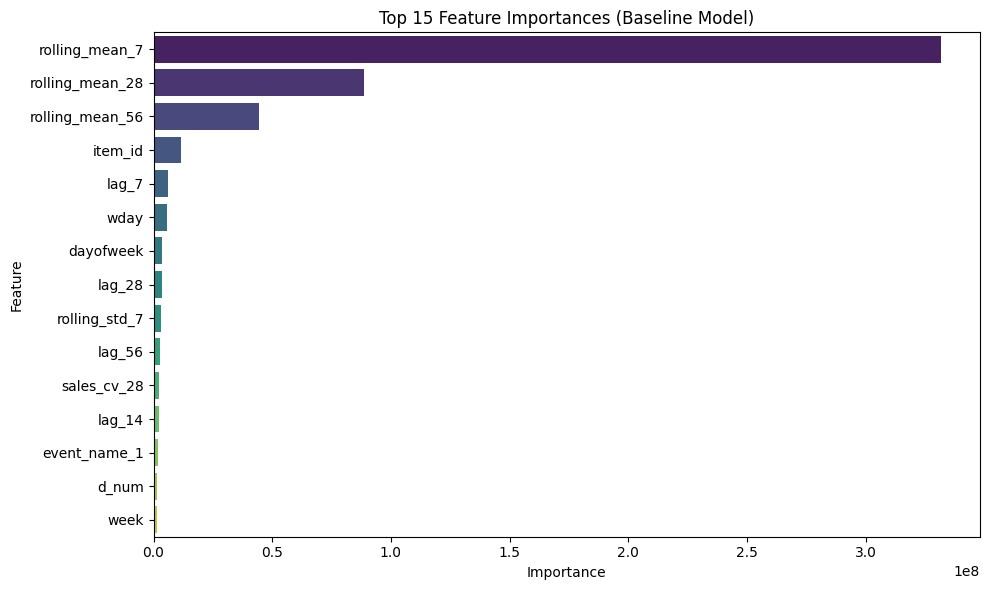

In [2]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Stage 2: Initializing Baseline Forecasting Model...")

# 1. THREE-WAY TIME-BASED SPLIT (Train, Calibration, Validation)
train_data = df[df['d_num'] < 1858]
cal_data = df[(df['d_num'] >= 1858) & (df['d_num'] < 1886)]
val_data = df[df['d_num'] >= 1886]

# Save calibration data to disk to free up RAM for Stage 4
cal_data.to_pickle('cal_data_stage4.pkl')
del cal_data
gc.collect()

# 2. SKU-BASED PROTOTYPE SAMPLING 
PROTOTYPE_FRAC = 0.25  # Set to 1.0 for the final overnight run
print(f"Sampling {PROTOTYPE_FRAC*100}% of SKUs for rapid prototyping...")

unique_ids = train_data['id'].unique()
sample_size = int(len(unique_ids) * PROTOTYPE_FRAC)
sample_ids = np.random.choice(unique_ids, size=sample_size, replace=False)

train_sample = train_data[train_data['id'].isin(sample_ids)]

# 3. HANDLE MISSING PRICES (For cleaner SHAP explanations later)
price_cols = ['sell_price', 'price_lag_7', 'price_change']
for col in price_cols:
    if col in train_sample.columns:
        train_sample.loc[:, col] = train_sample[col].fillna(0)
        val_data.loc[:, col] = val_data[col].fillna(0)

# 4. FEATURE EXTRACTION & CATEGORICAL EXPLICITNESS
features = [col for col in train_sample.columns if col not in ['id', 'sales']]
categorical_features = [c for c in features if str(train_sample[c].dtype) == 'category']

# 5. MEMORY OPTIMIZATION FOR VALIDATION
X_val = val_data[features]
y_val = val_data['sales']

del val_data
gc.collect()

# 6. CREATE LIGHTGBM DATASETS
d_train = lgb.Dataset(
    train_sample[features], 
    label=train_sample['sales'], 
    categorical_feature=categorical_features
)
d_val = lgb.Dataset(
    X_val, 
    label=y_val, 
    reference=d_train, 
    categorical_feature=categorical_features
)

del train_data, train_sample
gc.collect()

# 7. CONFIGURE BASELINE PARAMETERS
params = {
    'objective': 'regression',
    'metric': ['rmse', 'mae'],
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,          
    'min_data_in_leaf': 100,    
    'feature_fraction': 0.8,   
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'n_jobs': -1,              
    'seed': 42,
    'verbose': -1
}

# 8. TRAINING THE ENGINE
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

baseline_model = lgb.train(
    params,
    d_train,
    num_boost_round=1200,
    valid_sets=[d_train, d_val],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)

# 9. BUSINESS-FRIENDLY EVALUATION METRICS
print("Evaluating on Validation Set (Days 1886-1913)...")
preds = baseline_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)

print(f"Final RMSE: {rmse:.4f}")
print(f"Final MAE:  {mae:.4f}")

# 10. EXTRACT, PLOT & SAVE FEATURE IMPORTANCE
print("Extracting Feature Importance...")
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': baseline_model.feature_importance(importance_type='gain')
}).sort_values(by='Importance', ascending=False)

# Export for Round 2 PDF
importance_df.to_csv("baseline_feature_importance.csv", index=False)
print("Feature importance saved to 'baseline_feature_importance.csv'")

# Display Top Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (Baseline Model)')
plt.tight_layout()
plt.show()

# Stage 3 – Quantile Regression

Instead of predicting only a single demand estimate, three LightGBM quantile regression models are trained to estimate the lower (10th percentile), median (50th percentile), and upper (90th percentile) demand bounds. These predictions form the initial uncertainty interval for each SKU.

Stage 3: Initializing Quantile Regression Models (UQ Layer 1)...

 Training Lower Bound (q=0.10) - 
Training until validation scores don't improve for 30 rounds
[50]	train's quantile: 0.120868	valid's quantile: 0.130684
[100]	train's quantile: 0.120257	valid's quantile: 0.129998
[150]	train's quantile: 0.120061	valid's quantile: 0.129772
[200]	train's quantile: 0.119961	valid's quantile: 0.129677
[250]	train's quantile: 0.119895	valid's quantile: 0.129602
Early stopping, best iteration is:
[264]	train's quantile: 0.119895	valid's quantile: 0.129602

 Training Median Forecast (q=0.50) -
Training until validation scores don't improve for 30 rounds
[50]	train's quantile: 0.423149	valid's quantile: 0.454879
[100]	train's quantile: 0.415493	valid's quantile: 0.445511
[150]	train's quantile: 0.414773	valid's quantile: 0.444621
[200]	train's quantile: 0.414377	valid's quantile: 0.444184
[250]	train's quantile: 0.414133	valid's quantile: 0.444002
Early stopping, best iteration is:
[253]	train'

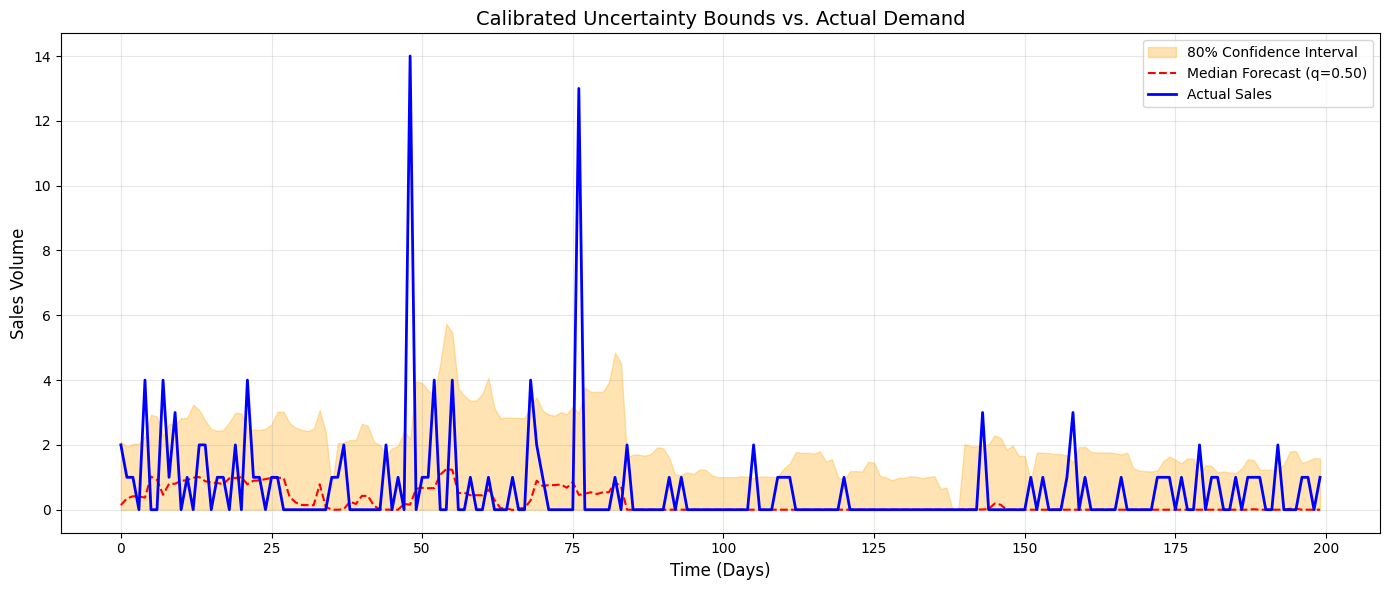

In [3]:
import lightgbm as lgb
import matplotlib.pyplot as plt

print("Stage 3: Initializing Quantile Regression Models (UQ Layer 1)...")

# 1. RECONSTRUCT THE PROTOTYPE SAMPLE 
train_data = df[df['d_num'] < 1858]
val_data = df[df['d_num'] >= 1886]

PROTOTYPE_FRAC = 0.25 # Set to 1.0 for final run
unique_ids = train_data['id'].unique()
np.random.seed(42) 
sample_size = int(len(unique_ids) * PROTOTYPE_FRAC)
sample_ids = np.random.choice(unique_ids, size=sample_size, replace=False)

train_sample = train_data[train_data['id'].isin(sample_ids)]

# Handle NaNs in prices
price_cols = ['sell_price', 'price_lag_7', 'price_change']
for col in price_cols:
    train_sample.loc[:, col] = train_sample[col].fillna(0)
    val_data.loc[:, col] = val_data[col].fillna(0)

features = [col for col in train_sample.columns if col not in ['id', 'sales']]
categorical_features = [c for c in features if str(train_sample[c].dtype) == 'category']

# Extract target and features
X_train = train_sample[features]
y_train = train_sample['sales']
X_val = val_data[features]
y_val = val_data['sales']

del train_data, train_sample, val_data
gc.collect()

# 2. CONFIGURE QUANTILE PARAMETERS
def get_quantile_params(alpha):
    return {
        'objective': 'quantile',
        'alpha': alpha,
        'metric': 'quantile',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 63,          
        'min_data_in_leaf': 100,    
        'feature_fraction': 0.8,   
        'n_jobs': -1,              
        'seed': 42,
        'verbose': -1
    }

d_train = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
d_val = lgb.Dataset(X_val, label=y_val, reference=d_train, categorical_feature=categorical_features)

# 3. TRAIN THE THREE QUANTILE MODELS
callbacks = [lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=50)]

print("\n Training Lower Bound (q=0.10) - ")
model_q10 = lgb.train(get_quantile_params(0.10), d_train, num_boost_round=800, 
                      valid_sets=[d_train, d_val], valid_names=['train', 'valid'], callbacks=callbacks)

print("\n Training Median Forecast (q=0.50) -")
model_q50 = lgb.train(get_quantile_params(0.50), d_train, num_boost_round=800, 
                      valid_sets=[d_train, d_val], valid_names=['train', 'valid'], callbacks=callbacks)

print("\n Training Upper Bound (q=0.90) -")
model_q90 = lgb.train(get_quantile_params(0.90), d_train, num_boost_round=800, 
                      valid_sets=[d_train, d_val], valid_names=['train', 'valid'], callbacks=callbacks)


# 4. GENERATE BOUNDS & EVALUATE METRICS
results_df = pd.DataFrame({
    'actual_sales': y_val.values,
    'lower_bound_q10': model_q10.predict(X_val),
    'median_q50': model_q50.predict(X_val),
    'upper_bound_q90': model_q90.predict(X_val)
})

# Quantile Crossing Fix
crossings = (results_df['lower_bound_q10'] > results_df['upper_bound_q90']).sum()
if crossings > 0:
    results_df['lower_bound_q10'] = np.minimum(results_df['lower_bound_q10'], results_df['upper_bound_q90'])

# Calculate Coverage & Width
coverage = ((results_df['actual_sales'] >= results_df['lower_bound_q10']) & 
            (results_df['actual_sales'] <= results_df['upper_bound_q90'])).mean()

results_df['interval_width'] = results_df['upper_bound_q90'] - results_df['lower_bound_q10']
avg_width = results_df['interval_width'].mean()

print(f"Empirical Coverage of 80% Interval: {coverage * 100:.2f}%")
print(f"Average Interval Width: {avg_width:.3f} units")

# 5. VISUALIZATION FOR PDF
sample_plot = results_df.head(200).reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.fill_between(sample_plot.index, sample_plot['lower_bound_q10'], sample_plot['upper_bound_q90'], 
                 alpha=0.3, color='orange', label='80% Confidence Interval')
plt.plot(sample_plot.index, sample_plot['median_q50'], color='red', linestyle='--', label='Median Forecast (q=0.50)')
plt.plot(sample_plot.index, sample_plot['actual_sales'], color='blue', linewidth=2, label='Actual Sales')

plt.title('Calibrated Uncertainty Bounds vs. Actual Demand', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Sales Volume', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stage 4 – Conformal Calibration

The quantile prediction intervals are calibrated using split conformal prediction. A held-out calibration set is used to provide finite-sample coverage guarantees without retraining the forecasting model.

Stage 4: Initiating Conformal Prediction (UQ Layer 2)...


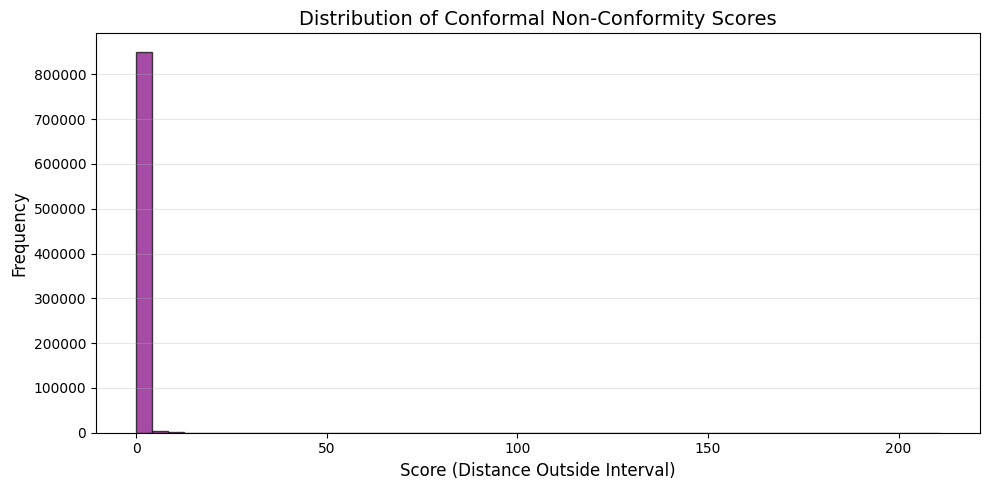

Conformal Adjustment Factor (q_hat): 0.0000
UNCERTAINTY QUANTIFICATION METRICS
Target Coverage:       80.00%
Stage 3 Coverage:      88.30%
  -> Mean Width:       2.874
  -> Median Width:     1.915

Stage 4 Coverage (CP): 88.55%
  -> Mean CP Width:    2.874
  -> Median CP Width:  1.915


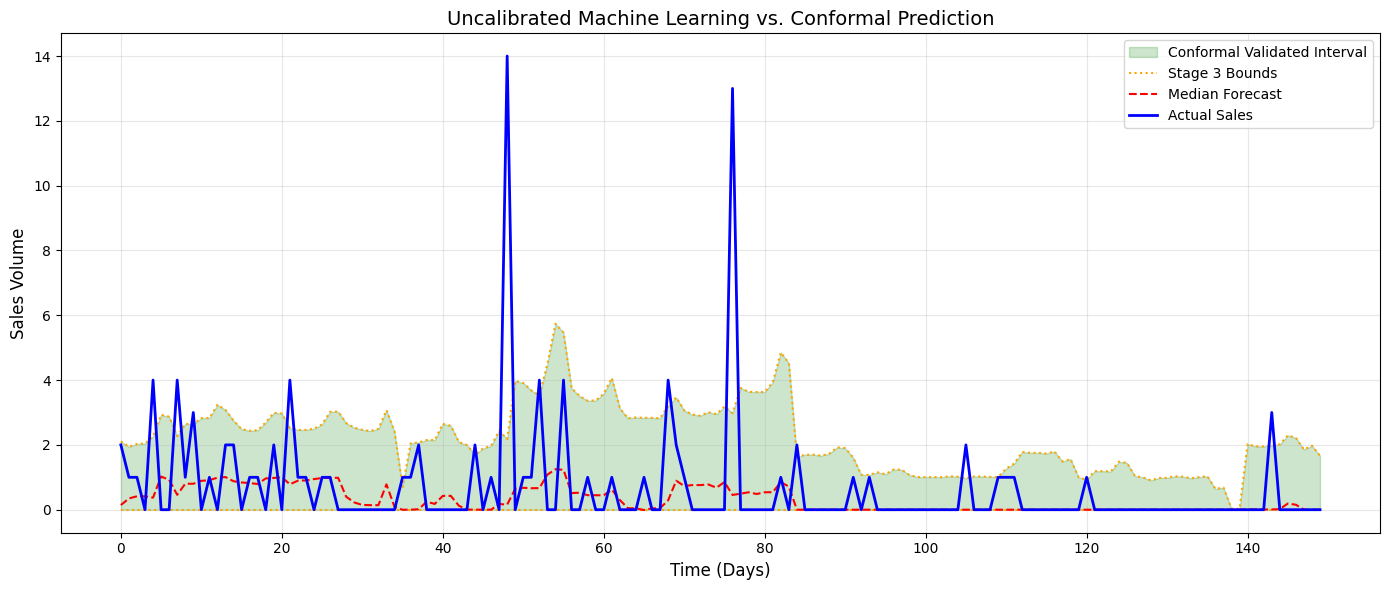

In [4]:
print("Stage 4: Initiating Conformal Prediction (UQ Layer 2)...")

# 1. LOAD CALIBRATION DATA
cal_data = pd.read_pickle('cal_data_stage4.pkl')

# Handle missing prices just like in training
price_cols = ['sell_price', 'price_lag_7', 'price_change']
for col in price_cols:
    if col in cal_data.columns:
        cal_data.loc[:, col] = cal_data[col].fillna(0)

# Ensure exact feature parity with Stage 3
features = [col for col in cal_data.columns if col not in ['id', 'sales']]
X_cal = cal_data[features]
y_cal = cal_data['sales'].values

del cal_data
gc.collect()

# 2. GENERATE CALIBRATION PREDICTIONS
cal_preds_q10 = model_q10.predict(X_cal)
cal_preds_q90 = model_q90.predict(X_cal)

# 3. CALCULATE STRICT NON-CONFORMITY SCORES
scores = np.maximum(
    0,
    np.maximum(cal_preds_q10 - y_cal, y_cal - cal_preds_q90)
)

plt.figure(figsize=(10, 5))
plt.hist(scores, bins=50, color='purple', alpha=0.7, edgecolor='black')
plt.title("Distribution of Conformal Non-Conformity Scores", fontsize=14)
plt.xlabel("Score (Distance Outside Interval)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. COMPUTE THE CALIBRATION FACTOR (q_hat)
alpha = 0.20
n = len(y_cal)
q_level = np.ceil((n + 1) * (1 - alpha)) / n

q_hat = np.quantile(scores, q_level, method="higher")

print(f"Conformal Adjustment Factor (q_hat): {q_hat:.4f}")

# 5. APPLY CONFORMAL ADJUSTMENT TO VALIDATION SET
conformal_q10 = results_df['lower_bound_q10'] - q_hat
conformal_q90 = results_df['upper_bound_q90'] + q_hat

# Prevent negative bounds and crossings
conformal_q10 = np.maximum(conformal_q10, 0)
conformal_q90 = np.maximum(conformal_q90, conformal_q10) 

results_df['conformal_lower_q10'] = conformal_q10
results_df['conformal_upper_q90'] = conformal_q90

# 6. EVALUATE THE UQ UPGRADE
conf_coverage = ((results_df['actual_sales'] >= results_df['conformal_lower_q10']) & 
                 (results_df['actual_sales'] <= results_df['conformal_upper_q90'])).mean()

results_df['conformal_width'] = results_df['conformal_upper_q90'] - results_df['conformal_lower_q10']
conf_avg_width = results_df['conformal_width'].mean()
conf_median_width = results_df['conformal_width'].median()

stage3_median_width = results_df['interval_width'].median()
print("UNCERTAINTY QUANTIFICATION METRICS")
print(f"Target Coverage:       80.00%")
print(f"Stage 3 Coverage:      {coverage * 100:.2f}%")
print(f"  -> Mean Width:       {avg_width:.3f}")
print(f"  -> Median Width:     {stage3_median_width:.3f}")
print(f"\nStage 4 Coverage (CP): {conf_coverage * 100:.2f}%")
print(f"  -> Mean CP Width:    {conf_avg_width:.3f}")
print(f"  -> Median CP Width:  {conf_median_width:.3f}")


# 7. VISUALIZE THE CONFORMAL UPGRADE (Before vs After)
sample_plot = results_df.head(150).reset_index(drop=True)

plt.figure(figsize=(14, 6))

plt.fill_between(sample_plot.index, sample_plot['conformal_lower_q10'], sample_plot['conformal_upper_q90'], 
                 alpha=0.2, color='green', label='Conformal Validated Interval')

plt.plot(sample_plot.index, sample_plot['upper_bound_q90'], color='orange', linestyle=':', label='Stage 3 Bounds')
plt.plot(sample_plot.index, sample_plot['lower_bound_q10'], color='orange', linestyle=':')

plt.plot(sample_plot.index, sample_plot['median_q50'], color='red', linestyle='--', label='Median Forecast')
plt.plot(sample_plot.index, sample_plot['actual_sales'], color='blue', linewidth=2, label='Actual Sales')

plt.title('Uncalibrated Machine Learning vs. Conformal Prediction', fontsize=14)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Sales Volume', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stage 5 – Explainable Risk Decomposition

SHAP values are computed to explain the model's predictions. Individual feature contributions are aggregated into business-oriented risk categories such as demand volatility, seasonality, and data reliability. These explanations are later consumed by the dashboard.

Stage 5: Initiating Explainable Risk Decomposition (SHAP)...


/tmp/ipykernel_57/164721641.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_matrix, X_shap, show=False)


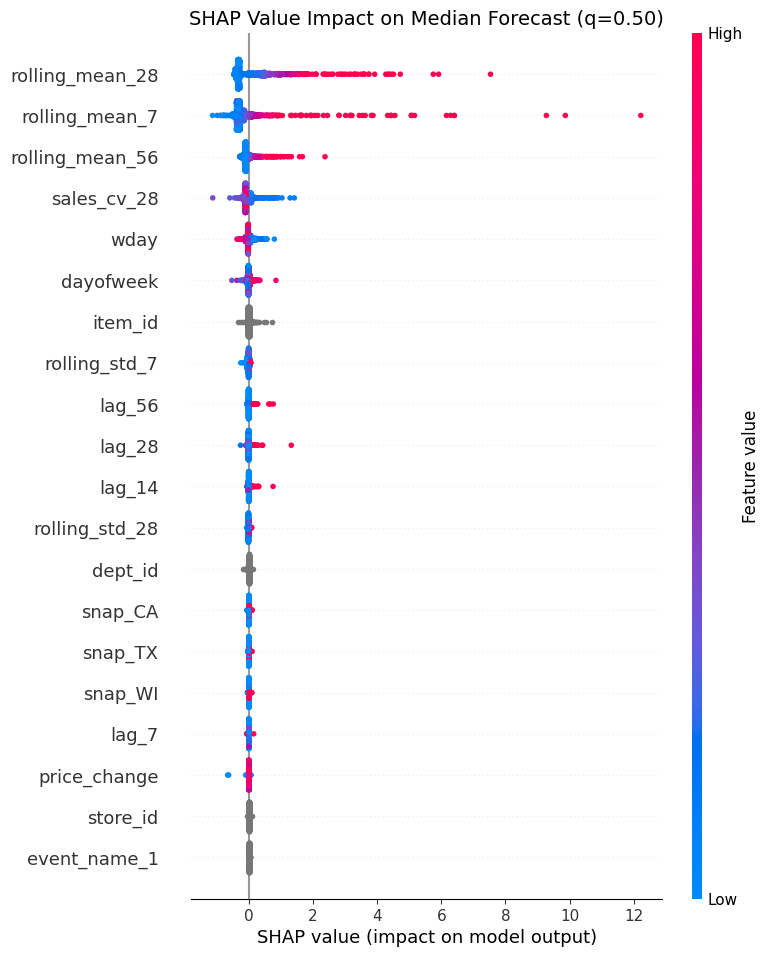

Pure Risk Driver Distribution (Excluding Base Trend):
Demand Volatility       70.2%
Seasonality & Events    28.6%
Data Reliability         1.2%
dtype: object

Dominant Pure-Risk Bucket:
Demand Volatility       80.9%
Seasonality & Events    19.0%
Data Reliability         0.1%
Name: proportion, dtype: object

Risk Complexity Score (Entropy):
Average Risk Entropy: 0.554
Pure Risk Triage Visualization...


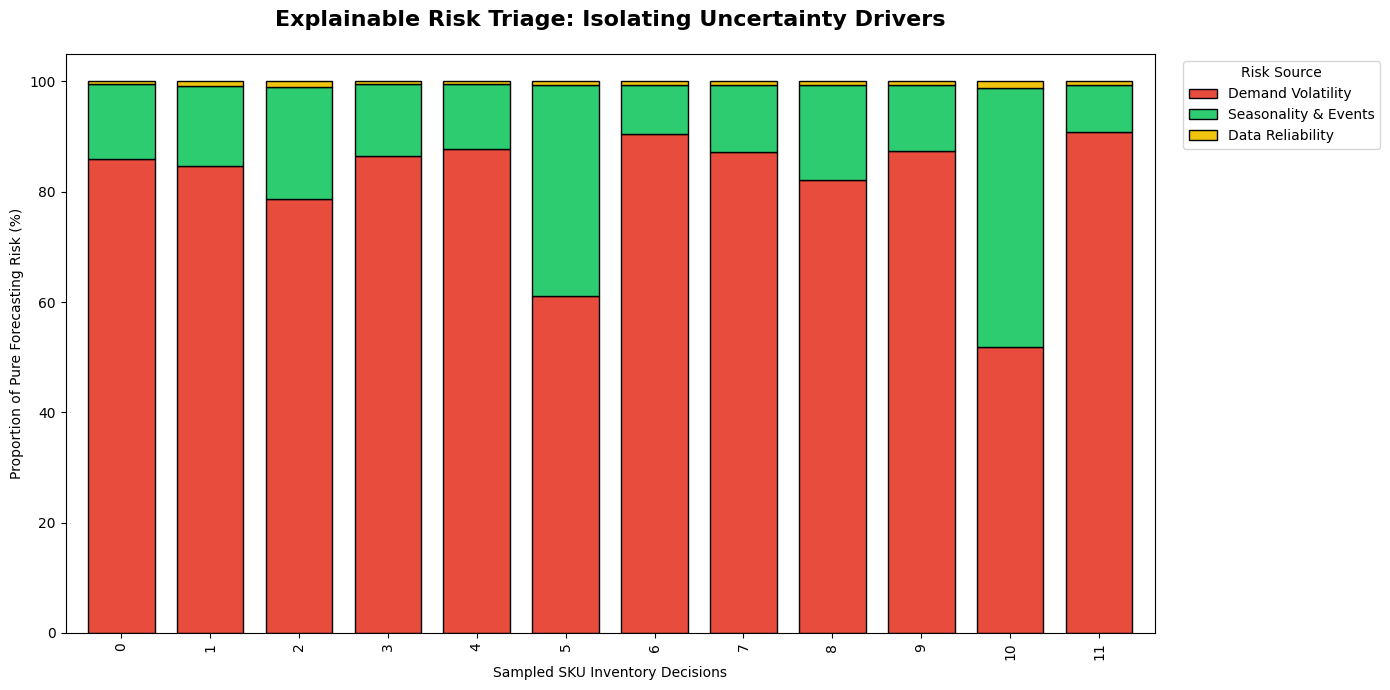

In [5]:
import shap
print("Stage 5: Initiating Explainable Risk Decomposition (SHAP)...")

# 1. SAMPLE VALIDATION DATA FOR SHAP
X_shap = X_val.sample(n=1000, random_state=42)

# 2. INITIALIZE TREE EXPLAINER (q=0.50)
explainer = shap.TreeExplainer(model_q50)
shap_values = explainer.shap_values(X_shap)
shap_matrix = shap_values.values if hasattr(shap_values, "values") else shap_values

# 3. CLASSIC SHAP BEESWARM PLOT
shap.summary_plot(shap_matrix, X_shap, show=False)
plt.title('SHAP Value Impact on Median Forecast (q=0.50)', fontsize=14)
plt.savefig('shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. DEFINE RISK BUCKETS
risk_mapping = {
    'Demand Trend': ['lag_7', 'lag_14', 'lag_28', 'lag_56', 'rolling_mean_7', 'rolling_mean_28', 'rolling_mean_56', 'd_num', 'days_since_start'],
    'Demand Volatility': ['rolling_std_7', 'rolling_std_28', 'sales_cv_28'],
    'Seasonality & Events': ['dayofweek', 'week', 'month', 'quarter', 'snap_CA', 'snap_TX', 'snap_WI', 'event_name_1', 'event_name_2', 'event_type_1', 'event_type_2'],
    'Data Reliability': ['sell_price', 'price_lag_7', 'price_change']
}

# 5. AGGREGATE SHAP VALUES
abs_shap = np.abs(shap_matrix)
feature_names = X_shap.columns.tolist()

risk_profiles = []
for i in range(len(X_shap)):
    profile = {k: 0 for k in risk_mapping.keys()}
    profile['Unmapped / Other'] = 0
    for j, feat in enumerate(feature_names):
        val = abs_shap[i, j]
        mapped = False
        for bucket, feats in risk_mapping.items():
            if feat in feats:
                profile[bucket] += val
                mapped = True
                break
        if not mapped:
            profile['Unmapped / Other'] += val
    risk_profiles.append(profile)

risk_df = pd.DataFrame(risk_profiles)

# 6. THE DUAL-VIEW SPLIT 
# View A: Forecast Drivers
forecast_pct = (risk_df.div(risk_df.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0)

# View B: Pure Risk Drivers
pure_risk_df = risk_df.drop(columns=['Demand Trend', 'Unmapped / Other'])
pure_risk_pct = (pure_risk_df.div(pure_risk_df.sum(axis=1).replace(0, np.nan), axis=0) * 100).fillna(0)

# 7. EXECUTIVE METRICS & ENTROPY 
print("Pure Risk Driver Distribution (Excluding Base Trend):")
pure_risk_importance = pure_risk_pct.mean().sort_values(ascending=False)
print(pure_risk_importance.round(1).astype(str) + '%')

print("\nDominant Pure-Risk Bucket:")
dominant_bucket = pure_risk_pct.idxmax(axis=1)
print(dominant_bucket.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\nRisk Complexity Score (Entropy):")
risk_entropy = -(pure_risk_pct/100 * np.log((pure_risk_pct/100)+1e-9)).sum(axis=1)
print(f"Average Risk Entropy: {risk_entropy.mean():.3f}")

# 8. EXPORT  
risk_df.to_csv("risk_profiles.csv", index=False)
forecast_pct.to_csv("forecast_driver_profiles.csv", index=False)
pure_risk_pct.to_csv("risk_profiles_dashboard.csv", index=False)
pure_risk_importance.to_csv("business_risk_importance.csv")

# 9. VISUALIZE THE *PURE RISK* TRIAGE ---
print("Pure Risk Triage Visualization...")
plot_data = pure_risk_pct.head(12)
colors = ['#e74c3c', '#2ecc71', '#f1c40f']

ax = plot_data.plot(
    kind='bar',
    stacked=True,
    color=colors,
    edgecolor='black',
    figsize=(14, 7),
    width=0.75
)

ax.set_title(
    'Explainable Risk Triage: Isolating Uncertainty Drivers',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xlabel('Sampled SKU Inventory Decisions')
ax.set_ylabel('Proportion of Pure Forecasting Risk (%)')
ax.legend(title='Risk Source', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('pure_risk_triage.png', dpi=300, bbox_inches='tight')
plt.show()

# Stage 6 – Decision Support & Dashboard Export

Forecasts, calibrated uncertainty intervals, explainability outputs, and business rules are combined to generate inventory recommendations. Each SKU is assigned a risk level and actionable recommendations, and the final dashboard-ready dataset is exported for the frontend.

In [6]:
import pandas as pd
import numpy as np

print("Stage 6: Cost-Aware Ordering, Volatility Audit, and Master Export...")

#  STAGE 6A: COST-AWARE ORDERING 
def calculate_reorder_point(median, upper_bound, stockout_penalty_ratio=3.0):
    risk_fraction = stockout_penalty_ratio / (stockout_penalty_ratio + 1.0)
    target = median + (upper_bound - median) * risk_fraction
    target = np.clip(target, median, upper_bound)
    return np.ceil(target) 

final_df = results_df.copy()
final_df['recommended_order_qty'] = calculate_reorder_point(
    final_df['median_q50'], 
    final_df['conformal_upper_q90'], 
    stockout_penalty_ratio=3.0 
)

#  STAGE 6B: VOLATILITY CALIBRATION AUDIT 
print("\nExecuting Volatility Calibration Audit...")
audit_df = final_df.copy()
audit_df['sales_cv_28'] = X_val['sales_cv_28'].values

# Create risk tiers
audit_df["volatility_tier"] = pd.qcut(
    audit_df["sales_cv_28"], 
    q=3, 
    labels=["Low", "Medium", "High"]
)
# Compute grouped metrics
def calculate_tier_metrics(group):
    coverage = ((group["actual_sales"] >= group["conformal_lower_q10"]) & 
                (group["actual_sales"] <= group["conformal_upper_q90"])).mean()
    width = (group["conformal_upper_q90"] - group["conformal_lower_q10"]).mean()
    mae = np.abs(group["actual_sales"] - group["median_q50"]).mean()
    return pd.Series({
        "Coverage": f"{coverage * 100:.1f}%", 
        "Mean Width": round(width, 2), 
        "MAE": round(mae, 2)
    })

audit_summary = audit_df.groupby(
    "volatility_tier",
    observed=False
).apply(calculate_tier_metrics, include_groups=False)

print("VOLATILITY AUDIT RESULTS ")
print(audit_summary.to_string())
audit_summary.to_csv('volatility_audit_summary.csv')

# STAGE 6C: DASHBOARD EXPORT 
print("\nMerging metrics into master dashboard payload...")

shap_indices = X_shap.index
position_idx = X_val.index.get_indexer(shap_indices)

# Extract correct rows and reset index for clean concatenation
dashboard_base = final_df.iloc[position_idx].reset_index(drop=True)

# Rename pure_risk_pct columns for the JSON API
api_pure_risk = pure_risk_pct.copy()
api_pure_risk.columns = [f"risk_driver_{c.lower().replace(' ', '_').replace('&', 'and')}" for c in api_pure_risk.columns]

# Concat gracefully
dashboard_df = pd.concat([
    dashboard_base,
    forecast_pct.reset_index(drop=True),
    api_pure_risk.reset_index(drop=True)
], axis=1)

dashboard_df['item_id'] = df.loc[shap_indices, 'id'].values
dashboard_df['day_index'] = df.loc[shap_indices, 'd_num'].values


float_cols = dashboard_df.select_dtypes(include=['float16', 'float32', 'float64']).columns
dashboard_df[float_cols] = dashboard_df[float_cols].round(2)

#  RISK TIER GENERATION 

dashboard_df["interval_width"] = (
    dashboard_df["conformal_upper_q90"]
    - dashboard_df["conformal_lower_q10"]
)

# Relative risk = uncertainty relative to expected demand
dashboard_df["relative_risk"] = (
    dashboard_df["interval_width"]
    / (dashboard_df["median_q50"] + 1e-5)
)

# Create business-friendly risk tiers
dashboard_df["risk_level"] = pd.qcut(
    dashboard_df["relative_risk"],
    q=4,
    labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"]
)

dashboard_df["primary_risk_driver"] = (
    api_pure_risk.idxmax(axis=1)
    .map({
        "risk_driver_demand_volatility": "Demand Volatility",
        "risk_driver_seasonality_and_events": "Seasonality And Events",
        "risk_driver_data_reliability": "Data Reliability"
    })
)

# BUSINESS DECISION ENGINE
DECISION_ENGINE = {

    ("LOW", "Demand Volatility"): [
        "Maintain current safety stock",
        "Continue routine demand monitoring",
        "No immediate intervention required"
    ],

    ("MEDIUM", "Demand Volatility"): [
        "Review safety stock levels",
        "Monitor demand over the next replenishment cycle",
        "Check reorder parameters"
    ],

    ("HIGH", "Demand Volatility"): [
        "Increase safety stock",
        "Shorten replenishment cycle",
        "Monitor demand daily"
    ],

    ("CRITICAL", "Demand Volatility"): [
        "Expedite replenishment",
        "Increase emergency inventory",
        "Notify inventory planner immediately"
    ],

    ("LOW", "Seasonality And Events"): [
        "Follow planned seasonal inventory",
        "Continue monitoring event calendar",
        "No additional action required"
    ],

    ("MEDIUM", "Seasonality And Events"): [
        "Review upcoming seasonal demand",
        "Coordinate with suppliers",
        "Validate promotion schedule"
    ],

    ("HIGH", "Seasonality And Events"): [
        "Increase inventory before seasonal peak",
        "Coordinate with suppliers early",
        "Review promotion calendar"
    ],

    ("CRITICAL", "Seasonality And Events"): [
        "Prioritize seasonal replenishment",
        "Escalate supplier coordination",
        "Review emergency inventory allocation"
    ],

    ("LOW", "Data Reliability"): [
        "Routine data quality monitoring",
        "Validate recent pricing updates",
        "No further action required"
    ],

    ("MEDIUM", "Data Reliability"): [
        "Validate pricing information",
        "Review inventory records",
        "Check recent data updates"
    ],

    ("HIGH", "Data Reliability"): [
        "Audit pricing and inventory data",
        "Investigate missing records",
        "Request planner verification"
    ],

    ("CRITICAL", "Data Reliability"): [
        "Manual planner review required",
        "Suspend automated ordering",
        "Validate all inventory inputs"
    ]
}


def decision_engine(row):

    key = (
        row["risk_level"],
        row["primary_risk_driver"]
    )

    if key in DECISION_ENGINE:
        return DECISION_ENGINE[key]

    return [
        "Maintain current inventory policy",
        "Continue routine monitoring",
        "Review forecast periodically"
    ]


dashboard_df["recommended_actions"] = dashboard_df.apply(
    decision_engine,
    axis=1
)

# Order columns logically
core_cols = [
    'item_id',
    'day_index',
    'actual_sales',
    'median_q50',
    'conformal_lower_q10',
    'conformal_upper_q90',
    'recommended_order_qty',
    'interval_width',
    'relative_risk',
    'risk_level',
    'primary_risk_driver',
    'recommended_actions'
]
all_output_cols = (
    core_cols
    + list(forecast_pct.columns)
    + list(api_pure_risk.columns)
)
dashboard_df = dashboard_df[all_output_cols]

print("Risk Tier Distribution:")
print(dashboard_df["risk_level"].value_counts())

print("Exporting Master Payload...")
dashboard_df.to_csv('master_dashboard_data.csv', index=False)
dashboard_df.to_json('master_dashboard_data.json', orient='records')

print(" FINISHED ")
print(f"Master dataset exported")

Stage 6: Cost-Aware Ordering, Volatility Audit, and Master Export...

Executing Volatility Calibration Audit...
VOLATILITY AUDIT RESULTS 
                Coverage  Mean Width   MAE
volatility_tier                           
Low                87.1%        4.96  1.50
Medium             89.0%        2.46  0.82
High               89.5%        1.18  0.34

Merging metrics into master dashboard payload...
Risk Tier Distribution:
risk_level
HIGH        258
LOW         250
MEDIUM      250
CRITICAL    242
Name: count, dtype: int64
Exporting Master Payload...
 FINISHED 
Master dataset exported
